# Credit Scoring — Give Me Some Credit & Home Credit

---
## Cấu trúc notebook

| Phần | Nội dung | Dùng chung? |
|------|----------|-------------|
| 0 | Setup & cài thư viện | Chung |
| 1 | Shared utilities (evaluate, plot, TabNet classes) | Chung |
| A | Give Me Some Credit — Load → EDA → FE → Preprocess → Train | Riêng |
| B | Home Credit — Load → Aggregate → EDA → FE → Preprocess → Train | Riêng |
| C | So sánh kết quả giữa 2 dataset | Chung |
| D | Lưu model để demo | Dùng theo GMSC |

# 0. Setup & Reproducibility

In [1]:
import os, sys, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
SAVE_DIR   = f'{OUTPUT_DIR}/saved_models'


print("python  :", sys.version)
print("platform:", platform.platform())
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)


python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
numpy   : 2.4.6
pandas  : 2.3.3


In [2]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

In [3]:
import torch
import optuna
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
)
from category_encoders import WOEEncoder
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')


Imports OK


In [4]:
!pip install pytorch_tabnet 
from pytorch_tabnet.tab_model import TabNetClassifier
print('pytorch_tabnet OK')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.5 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23

---
# 1. Shared Utilities
> Tất cả hàm dùng chung cho cả 2 dataset.  
> Chạy một lần, dùng xuyên suốt notebook.


## 1.1 Evaluate metrics

In [5]:
def evaluate(model, X, y_true, label='', threshold=None):
    y_prob = model.predict_proba(X)[:, 1]
    y_true = np.array(y_true)
    auc    = roc_auc_score(y_true, y_prob)
    ap     = average_precision_score(y_true, y_prob)
    gini   = 2 * auc - 1
    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    ks_scores   = tpr - fpr
    ks          = ks_scores.max()
    
    if threshold is not None:
        best_thresh = threshold
    else:
        best_thresh = float(thr_roc[ks_scores.argmax()])
    
    y_pred      = (y_prob >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_bad     = tp / (tp + fn + 1e-8)
    recall_good    = tn / (tn + fp + 1e-8)
    precision_bad  = tp / (tp + fp + 1e-8)
    f1_bad         = 2 * precision_bad * recall_bad / (precision_bad + recall_bad + 1e-8)
    if label:
        print(f"  [{label}] AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1(bad)={f1_bad:.4f}")
    return dict(auc=auc, gini=gini, ks=ks, ap=ap, threshold=best_thresh,
                recall_bad=recall_bad, recall_good=recall_good,
                precision_bad=precision_bad, f1_bad=f1_bad,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))

## 1.2 Summarize & 1.3 Plot baseline results

In [6]:
def summarize_results(results):
    rows = []
    for name, r in results.items():
        tr, te = r['train'], r['test']
        rows.append({
            'Model'          : name,
            'Train AUC'      : round(tr['auc'],           4),
            'Test AUC'       : round(te['auc'],           4),
            'Test Gini'      : round(te['gini'],          4),
            'Test KS'        : round(te['ks'],            4),
            'Precision (Bad)': round(te['precision_bad'], 4),
            'Recall (Bad)'   : round(te['recall_bad'],    4),
            'Recall (Good)'  : round(te['recall_good'],   4),
            'F1 (Bad)'       : round(te['f1_bad'],        4),
            'TP': int(te['tp']), 'FP': int(te['fp']),
            'TN': int(te['tn']), 'FN': int(te['fn']),
            'Threshold'      : round(te['threshold'],     4),
            'Train Time (s)' : r['train_time_s'],
        })
    return (pd.DataFrame(rows)
              .sort_values('Test AUC', ascending=False)
              .reset_index(drop=True))

def append_to_summary(df_summary, model_name, train_m, test_m, train_time=None):
    new_row = pd.DataFrame([{
        'Model'          : model_name,
        'Train AUC'      : round(train_m['auc'],           4),
        'Test AUC'       : round(test_m['auc'],            4),
        'Test Gini'      : round(test_m['gini'],           4),
        'Test KS'        : round(test_m['ks'],             4),
        'Precision (Bad)': round(test_m['precision_bad'],  4),
        'Recall (Bad)'   : round(test_m['recall_bad'],     4),
        'Recall (Good)'  : round(test_m['recall_good'],    4),
        'F1 (Bad)'       : round(test_m['f1_bad'],         4),
        'TP': int(test_m['tp']), 'FP': int(test_m['fp']),
        'TN': int(test_m['tn']), 'FN': int(test_m['fn']),
        'Threshold'      : round(test_m['threshold'],      4),
        'Train Time (s)' : train_time,
    }])
    df_summary = df_summary[df_summary['Model'] != model_name].reset_index(drop=True)
    return (pd.concat([df_summary, new_row], ignore_index=True)
              .sort_values('Test AUC', ascending=False)
              .reset_index(drop=True))


def plot_baseline(df_summary, title_suffix='', output_dir=OUTPUT_DIR):
    tag   = title_suffix.replace(' ', '_').lower()
    names = df_summary['Model']
    x     = np.arange(len(names))
    w     = 0.18

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (m, c) in enumerate(zip(
        ['Test AUC','Test Gini','Test KS','F1 (Bad)','Recall (Bad)'],
        ['#2E86C1','#1ABC9C','#E67E22','#8E44AD','#E74C3C']
    )):
        ax.bar(x + i*w, df_summary[m], w, label=m, color=c, alpha=0.85)
    ax.set_xticks(x + w*2)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'Baseline Comparison {title_suffix}', fontsize=13)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/baseline_metrics_{tag}.png', dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x-w/2, df_summary['Train AUC'], w, label='Train AUC', color='#2E86C1', alpha=0.85)
    ax.bar(x+w/2, df_summary['Test AUC'],  w, label='Test AUC',  color='#E74C3C', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'Train vs Test AUC — Overfit Check {title_suffix}', fontsize=13)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/overfit_check_{tag}.png', dpi=150)
    plt.show()


def plot_final(results_baseline, extra_models, X_test_bl, y_test,
               df_summary, title_suffix='', output_dir=OUTPUT_DIR):
    tag  = title_suffix.lower().replace(' ', '_')
    y_te = y_test.values if hasattr(y_test, 'values') else y_test

    plot_models = [(n, results_baseline[n]['model'], X_test_bl, '#B4B2A9')
                   for n in ['LightGBM', 'CatBoost'] if n in results_baseline]
    plot_models += extra_models

    # ROC
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, model, X_eval, color in plot_models:
        y_prob       = model.predict_proba(X_eval)[:, 1]
        fpr, tpr, _  = roc_curve(y_te, y_prob)
        auc          = roc_auc_score(y_te, y_prob)
        lw = 2.5 if 'TabNet' in name else 1.5
        ls = '-'  if 'TabNet' in name else '--'
        ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
                label=f'{name} (AUC={auc:.4f})')
    ax.plot([0,1],[0,1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {title_suffix}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/roc_{tag}.png', dpi=150)
    plt.show()

    # PR
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, model, X_eval, color in plot_models:
        y_prob       = model.predict_proba(X_eval)[:, 1]
        prec, rec, _ = precision_recall_curve(y_te, y_prob)
        ap           = average_precision_score(y_te, y_prob)
        lw = 2.5 if 'TabNet' in name else 1.5
        ls = '-'  if 'TabNet' in name else '--'
        ax.plot(rec, prec, color=color, linewidth=lw, linestyle=ls,
                label=f'{name} (AP={ap:.4f})')
    ax.axhline(y_te.mean(), color='gray', linestyle=':', alpha=0.6, label='Random')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall — {title_suffix}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/pr_{tag}.png', dpi=150)
    plt.show()

    # Final bar
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    bar_colors = [
        '#534AB7' if 'Stacking' in m
        else '#1D9E75' if 'Improved' in m or 'MHA' in m
        else '#9FE1CB' if 'single' in m or 'no-FE' in m
        else '#B4B2A9'
        for m in df_summary['Model']
    ]
    for ax, metric in zip(axes, ['Test AUC', 'Test KS', 'F1 (Bad)']):
        bars = ax.barh(df_summary['Model'], df_summary[metric],
                       color=bar_colors, alpha=0.88, height=0.6)
        ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
        ax.set_xlim(df_summary[metric].min()-0.01, df_summary[metric].max()+0.02)
        ax.set_title(metric)
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()
    plt.suptitle(f'Final Model Comparison — {title_suffix}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/final_comparison_{tag}.png', dpi=150)
    plt.show()

## 1.4 Preprocessing

In [7]:
def impute_median_group(X_train, X_test, group_col, target_col):
    medians    = X_train.groupby(group_col, observed=True)[target_col].median()
    global_med = X_train[target_col].median()
    for df in [X_train, X_test]:
        mask = df[target_col].isna()
        df.loc[mask, target_col] = df.loc[mask, group_col].map(medians).fillna(global_med)
    return X_train, X_test


def impute_all_numeric(X_train, X_test, skip_cols=None):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        X_test[col]  = X_test[col].fillna(med)
    return X_train, X_test


def cap_iqr(X_train, X_test, skip_cols=None, p_low=5, p_high=95):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        data = X_train[col].dropna()
        Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
        IQR    = Q3 - Q1
        if ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).any():
            lo = np.percentile(data, p_low)
            hi = np.percentile(data, p_high)
            X_train[col] = X_train[col].clip(lo, hi)
            X_test[col]  = X_test[col].clip(lo, hi)
    return X_train, X_test

In [8]:
def encode_categoricals(X_train, X_test):
    """LabelEncoder cho tất cả object/category cols — dùng cho TabNet pipeline."""
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col]  = le.transform(X_test[col].astype(str))
        encoders[col] = le
    return X_train, X_test, encoders


def apply_woe_scale(X_train, X_test, y_train):
    """WOE encode cat cols + StandardScaler num cols — dùng cho baseline."""
    X_train, X_test = X_train.copy(), X_test.copy()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    woe_enc  = None
    if cat_cols:
        woe_enc = WOEEncoder(cols=cat_cols, handle_unknown='value', handle_missing='value')
        woe_enc.fit(X_train[cat_cols], y_train)
        X_train[cat_cols] = woe_enc.transform(X_train[cat_cols])
        X_test[cat_cols]  = woe_enc.transform(X_test[cat_cols])
    scaler = StandardScaler()
    if num_cols:
        scaler.fit(X_train[num_cols])
        X_train[num_cols] = scaler.transform(X_train[num_cols])
        X_test[num_cols]  = scaler.transform(X_test[num_cols])
    return X_train, X_test, woe_enc, scaler

In [9]:
def preprocess_for_tabnet(X_train, X_test, skip_impute_cols=None):
    X_train, X_test = X_train.copy(), X_test.copy()
    
    # 1. Encode categoricals
    X_train, X_test, encoders = encode_categoricals(X_train, X_test)
    
    # 2. Impute TRƯỚC khi transform
    X_train, X_test = impute_all_numeric(X_train, X_test, skip_cols=skip_impute_cols)
    
    # 3. QuantileTransform
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    qt = QuantileTransformer(output_distribution='normal', 
                              n_quantiles=min(1000, len(X_train)),  # tránh n_quantiles > n_samples
                              random_state=42)
    qt.fit(X_train[num_cols])
    X_train[num_cols] = qt.transform(X_train[num_cols])
    X_test[num_cols]  = qt.transform(X_test[num_cols])
    
    # 4. Clip outlier sau transform (QT không hoàn toàn loại outlier với unseen data)
    X_train[num_cols] = X_train[num_cols].clip(-5, 5)
    X_test[num_cols]  = X_test[num_cols].clip(-5, 5)
    
    print(f'  TabNet input: train={X_train.shape} | test={X_test.shape}')
    return X_train, X_test, qt

## 1.5 Baseline models 

In [10]:
def build_baseline_models(bad_weight, n_samples=10000):
    min_leaf = max(20, n_samples // 2000)
    return {     
        'Logistic Regression': LogisticRegression(
        class_weight={0:1, 1:bad_weight},
        random_state=42),                    
    
        'Decision Tree': DecisionTreeClassifier(
        class_weight={0:1, 1:bad_weight},
        max_depth=6,   
        random_state=42),                    
    
        'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=min_leaf,
        max_features='sqrt',
        class_weight={0: 1, 1: bad_weight},
        random_state=RANDOM_SEED,
        n_jobs=-1),                                   
        
        'XGBoost': XGBClassifier(
            scale_pos_weight=bad_weight,
            eval_metric='auc',
            random_state=42,
            verbosity=0),                        
        
        'LightGBM': LGBMClassifier(
            scale_pos_weight=bad_weight,
            random_state=42,
            verbose=-1),
        
        'CatBoost': CatBoostClassifier(
            scale_pos_weight=bad_weight,
            random_seed=42,
            verbose=0),
       
    }



def train_baseline_models(models, X_tr, X_te, y_tr, y_te):
    results = {}
    for name, model in models.items():
        print(f'  Training {name} ...', end=' ')
        t0 = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0
        print(f'({elapsed:.1f}s)')
        y_te_np = y_te.values if hasattr(y_te, 'values') else np.array(y_te)
        y_prob  = model.predict_proba(X_te)[:, 1]
        te_m    = evaluate(model, X_te, y_te, label='test')
        results[name] = {
            'model'       : model,
            'train'       : evaluate(model, X_tr, y_tr, label='train'),
            'test'        : te_m,
            'train_time_s': round(elapsed, 2),
            'y_true'      : y_te_np,
            'y_prob'      : y_prob,
            'auc'         : te_m['auc'],
        }
    return results

## 1.6 TabNet architecture (ImprovedTabNet)

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha, self.gamma, self.pos_weight = alpha, gamma, pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


class MultiHeadAttention(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k  = d_model // n_heads
        self.W_Q  = nn.Linear(1, d_model)
        self.W_K  = nn.Linear(1, d_model)
        self.W_V  = nn.Linear(1, d_model)
        self.W_O  = nn.Linear(d_model, 1)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(n_features)

    def forward(self, x):
        B, F_ = x.shape
        t     = x.unsqueeze(-1)
        Q, K, V = self.W_Q(t), self.W_K(t), self.W_V(t)
        def sh(z): return z.view(B, F_, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = sh(Q), sh(K), sh(V)
        A   = self.drop(torch.softmax(Q @ K.transpose(-2,-1) / self.d_k**0.5, dim=-1))
        out = (A @ V).transpose(1,2).contiguous().view(B, F_, self.d_model)
        return self.norm(self.W_O(out).squeeze(-1) + x)

In [12]:
class ImprovedTabNetClassifier(nn.Module):
    def __init__(self, n_features, n_d=64, n_steps=5,
                 n_heads=8, d_model=64, dropout=0.1, gamma=1.5,
                 use_mha=True):                          # <-- THÊM
        super().__init__()
        self.n_features, self.n_steps, self.n_d, self.gamma = n_features, n_steps, n_d, gamma
        self.use_mha = use_mha                            # <-- THÊM

        if self.use_mha:
            self.mha_local  = MultiHeadAttention(n_features, d_model, n_heads,   dropout)
            self.mha_global = MultiHeadAttention(n_features, d_model*2, n_heads*2, dropout)
            shared_in_dim = n_features * 3
        else:
            self.mha_local  = None
            self.mha_global = None
            shared_in_dim = n_features                    # <-- THÊM: bỏ MHA thì input nhỏ lại

        self.shared_fc = nn.Sequential(
            nn.Linear(shared_in_dim, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))

        self.step_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))
            for _ in range(n_steps)])

        self.attn_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_features), nn.Softmax(dim=-1))
            for _ in range(n_steps)])

        self.proj_fc = nn.ModuleList([
            nn.Linear(n_features, n_d, bias=False)
            for _ in range(n_steps)])

        self.bn_in = nn.BatchNorm1d(n_features)
        self.drop  = nn.Dropout(dropout)
        self.head  = nn.Linear(n_d, 1)

    def _encode(self, x):
        x = self.bn_in(x)

        if self.use_mha:                                  # <-- THÊM
            h_input = torch.cat([x, self.mha_local(x), self.mha_global(x)], dim=-1)
        else:
            h_input = x

        h = self.shared_fc(h_input)
        prior = torch.ones(x.size(0), self.n_features, device=x.device)
        agg   = torch.zeros(x.size(0), self.n_d,       device=x.device)
        ent   = torch.zeros(1,                          device=x.device)

        for i in range(self.n_steps):
            mask  = self.attn_fc[i](h) * prior
            mask  = mask / (mask.sum(-1, keepdim=True) + 1e-8)
            prior = prior * (self.gamma - mask)
            ent   = ent + (-mask * torch.log(mask + 1e-15)).sum(-1).mean()

            proj  = torch.relu(self.proj_fc[i](mask * x))
            step_out = torch.relu(self.step_fc[i](h) + proj * 0.5)
            agg  += step_out
            h = h + self.drop(step_out)

        return agg / self.n_steps, ent / self.n_steps

    def get_embedding(self, x):
        emb, _ = self._encode(x)
        return emb

    def forward(self, x):
        emb, ent = self._encode(x)
        return self.head(emb).squeeze(-1), ent

In [13]:
class ModelWrapper:
    def __init__(self, model, device):
        self.model, self.device = model, device

    def predict_proba(self, X):
        if hasattr(X, 'values'): X = X.values
        self.model.eval()
        out = []
        with torch.no_grad():
            for (xb,) in DataLoader(
                TensorDataset(torch.tensor(X.astype(np.float32))), batch_size=2048):
                lg, _ = self.model(xb.to(self.device))
                out.append(torch.sigmoid(lg).cpu().numpy())
        p = np.concatenate(out)
        return np.column_stack([1-p, p])


class MetaWrapper:
    def __init__(self, models, lgbm):
        self.models, self.lgbm = models, lgbm

    def predict_proba(self, X):
        if hasattr(X, 'values'): X = X.values
        X = X.astype(np.float32)
        actual_n_d = self.models[0][0].head.in_features
        if X.shape[1] == actual_n_d + 1:
            return self.lgbm.predict_proba(X)
        avg_p = np.zeros(len(X))
        avg_e = np.zeros((len(X), actual_n_d))
        for m, d in self.models:
            avg_p += infer_batch(m, X, d, mode='proba')     / len(self.models)
            avg_e += infer_batch(m, X, d, mode='embedding') / len(self.models)
        return self.lgbm.predict_proba(np.hstack([avg_e, avg_p.reshape(-1,1)]))

In [14]:
def infer_batch(model, X_np, device, batch_size=2048, mode='proba'):
    if hasattr(X_np, 'values'): X_np = X_np.values
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[s:s+batch_size].astype(np.float32)).to(device)
            if mode == 'proba':
                lg, _ = model(xb)
                out.append(torch.sigmoid(lg).cpu().numpy())
            else:
                out.append(model.get_embedding(xb).cpu().numpy())
            torch.cuda.empty_cache()
    return np.concatenate(out) if mode == 'proba' else np.vstack(out)

print('✓ Architecture classes ready')

✓ Architecture classes ready


## 1.7 Train Improved TabNet 

In [15]:
def train_improved_tabnet(
    X_train, X_test, y_train, y_test, bad_weight,
    n_d=64, n_steps=5, n_heads=8, d_model=64,
    dropout=0.1, gamma=1.5, lambda_sparse=1e-4, focal_gamma=2.0,
    lr=1e-3, weight_decay=1e-5, batch_size=1024,
    max_epochs=150, patience=20, verbose_every=10,
    warmup_epochs=0, seed=42,
    loss_type='focal',   # 'focal' hoặc 'bce'
    use_mha=True,        # <-- THÊM
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)   # sửa luôn dùng seed thay vì hard-code 42
    np.random.seed(seed)                                              # sửa luôn dùng seed thay vì hard-code 42

    def to_np(z, dt): return z.values.astype(dt) if hasattr(z,'values') else np.array(z, dtype=dt)
    X_tr = torch.tensor(to_np(X_train, np.float32))
    X_te = torch.tensor(to_np(X_test,  np.float32))
    y_tr = torch.tensor(to_np(y_train, np.float32))
    y_te = torch.tensor(to_np(y_test,  np.float32))

    if loss_type == 'focal':
        crit = FocalLoss(0.75, focal_gamma, torch.tensor([bad_weight]).to(device))
    elif loss_type == 'bce':
        crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bad_weight]).to(device))
    else:
        raise ValueError("loss_type phải là 'focal' hoặc 'bce'")

    train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size,
                          shuffle=True, pin_memory=True)
    test_dl  = DataLoader(TensorDataset(X_te, y_te), batch_size=2048,
                          shuffle=False, pin_memory=True)

    model = ImprovedTabNetClassifier(
        X_tr.shape[1], n_d, n_steps, n_heads, d_model, dropout, gamma,
        use_mha=use_mha).to(device)                       # <-- THÊM use_mha

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if warmup_epochs > 0:
        warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
        cosine = CosineAnnealingLR(opt, T_max=max_epochs - warmup_epochs, eta_min=1e-6)
        sch    = SequentialLR(opt, schedulers=[warmup, cosine], milestones=[warmup_epochs])
    else:
        sch    = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-6)

    best_auc, best_state, no_imp, history = 0.0, None, 0, []
    t0 = time.time()
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            lg, ent = model(xb)
            (crit(lg, yb) + lambda_sparse * ent).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()
        model.eval(); ps, ls = [], []
        with torch.no_grad():
            for xb, yb in test_dl:
                lg, _ = model(xb.to(device))
                ps.append(torch.sigmoid(lg).cpu()); ls.append(yb)
        auc = roc_auc_score(torch.cat(ls).numpy(), torch.cat(ps).numpy())
        history.append(auc)
        if (epoch+1) % verbose_every == 0 or epoch == 0:
            print(f'    Epoch {epoch+1:3d} | test_auc={auc:.5f} | {time.time()-t0:.0f}s')
        if auc > best_auc + 1e-5:
            best_auc   = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp     = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f'    Early stop @ epoch {epoch+1} | best={best_auc:.5f}')
                break

    model.load_state_dict(best_state)
    model.to(device)
    wrapper = ModelWrapper(model, device)
    tr_m = evaluate(wrapper, to_np(X_train, np.float32), to_np(y_train, np.int64), label='train')
    te_m = evaluate(wrapper, to_np(X_test,  np.float32), to_np(y_test,  np.int64), label='test')
    print(f'  Done {time.time()-t0:.1f}s | Train AUC={tr_m["auc"]:.4f} | '
          f'Test AUC={te_m["auc"]:.4f} | Gap={tr_m["auc"]-te_m["auc"]:.4f}')
    return wrapper, tr_m, te_m, history, model, device

print('✓ Architecture classes ready (with use_mha toggle)')

✓ Architecture classes ready (with use_mha toggle)


## 1.8 SHAP 

In [16]:
def run_shap_analysis(model_raw, X_train_np, X_test_np, y_test_np,
                       feat_names, tag='', output_dir=OUTPUT_DIR,
                       n_background=500, n_explain=500):
    """
    Dùng GradientExplainer thay KernelExplainer — nhanh hơn 100x trên GPU.
    model_raw: raw PyTorch module (không phải wrapper).
    """
    device = next(model_raw.parameters()).device
    model_raw.eval()

    # Wrapper để GradientExplainer hiểu (output scalar probability)
    class _ShapModel(nn.Module):
        def __init__(self, base): super().__init__(); self.base = base
        def forward(self, x):
            lg, _ = self.base(x)
            return torch.sigmoid(lg).unsqueeze(1)

    shap_model = _ShapModel(model_raw)

    # Background: sample ngẫu nhiên từ train
    np.random.seed(42)
    bg_idx  = np.random.choice(len(X_train_np), size=n_background, replace=False)
    X_bg    = torch.tensor(X_train_np[bg_idx]).to(device)

    # Explain samples từ test
    ex_idx  = np.random.choice(len(X_test_np), size=n_explain, replace=False)
    X_ex    = torch.tensor(X_test_np[ex_idx]).to(device)

    explainer  = shap.GradientExplainer(shap_model, X_bg)
    shap_vals  = explainer.shap_values(X_ex)

    # GradientExplainer returns list for multi-output; take [0] and squeeze
    if isinstance(shap_vals, list):
        sv = shap_vals[0]
    else:
        sv = shap_vals
    if sv.ndim == 3:
        sv = sv[:, :, 0]  # (N, F, 1) → (N, F)

    sv_np = sv if isinstance(sv, np.ndarray) else sv.cpu().numpy()
    X_ex_np = X_ex.cpu().numpy()

    # ── Bar plot (mean |SHAP|) ────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_np, X_ex_np, feature_names=feat_names,
                      plot_type='bar', max_display=15, show=False)
    plt.title(f'SHAP Feature Importance — Improved TabNet ({tag})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/shap_bar_{tag.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Beeswarm ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv_np, X_ex_np, feature_names=feat_names,
                      max_display=15, show=False)
    plt.title(f'SHAP Beeswarm — Improved TabNet ({tag})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/shap_beeswarm_{tag.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Local waterfall: 1 bad + 1 good ──────────────────────────────────────
    y_ex = y_test_np[ex_idx]
    bad_idx  = np.where(y_ex == 1)[0]
    good_idx = np.where(y_ex == 0)[0]

    if len(bad_idx) > 0 and len(good_idx) > 0:
        try:
            base_val = float(np.mean(torch.sigmoid(
                shap_model(X_bg)).detach().cpu().numpy()))
        except:
            base_val = 0.5
        for si, label in [(bad_idx[0], 'bad_customer'), (good_idx[0], 'good_customer')]:
            exp = shap.Explanation(
                values        = sv_np[si],
                base_values   = base_val,
                data          = X_ex_np[si],
                feature_names = feat_names
            )
            plt.figure(figsize=(10, 6))
            shap.waterfall_plot(exp, max_display=12, show=False)
            plt.title(f'SHAP Waterfall — {label.replace("_"," ").title()} ({tag})', fontsize=12)
            plt.tight_layout()
            plt.savefig(f'{output_dir}/shap_waterfall_{tag.lower().replace(" ","_")}_{label}.png',
                        dpi=150, bbox_inches='tight')
            plt.show()

    # ── Mean |SHAP| summary ───────────────────────────────────────────────────
    mean_shap = pd.Series(np.abs(sv_np).mean(axis=0), index=feat_names).sort_values(ascending=False)
    print(f'\nTop 10 SHAP features ({tag}):')
    print(mean_shap.head(10).to_string())
    mean_shap.to_csv(f'{output_dir}/shap_importance_{tag.lower().replace(" ","_")}.csv')
    return sv_np, mean_shap

## 1.9 Risk tiering

In [17]:
def run_risk_tiering(wrapper, X_np, y_np, tag='', output_dir=OUTPUT_DIR,
                     bins=[0, 0.1, 0.3, 0.5, 1.0],
                     labels=['Low (0–10%)', 'Medium (10–30%)', 'High (30–50%)', 'Very High (>50%)']):
    prob = wrapper.predict_proba(X_np)[:, 1]
    df   = pd.DataFrame({'prob': prob, 'actual': y_np})
    bins   = [0, 0.1, 0.3, 0.5, 1.0]
    labels = ['Low (0–10%)', 'Medium (10–30%)', 'High (30–50%)', 'Very High (>50%)']
    df['tier'] = pd.cut(df['prob'], bins=bins, labels=labels, include_lowest=True)
    stats = df.groupby('tier', observed=True).agg(
        Count   = ('actual', 'count'),
        Bad_Rate= ('actual', 'mean'),
        Avg_Prob= ('prob',   'mean')
    ).reset_index()
    stats['Bad_Rate_pct'] = (stats['Bad_Rate'] * 100).round(2)
    print(f'\n── Risk Tiering ({tag}) ──')
    print(stats.to_string(index=False))
    stats.to_csv(f'{output_dir}/risk_tiering_{tag.lower().replace(" ","_")}.csv', index=False)

    colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(stats['tier'], stats['Bad_Rate_pct'], color=colors, alpha=0.85)
    axes[0].set_title(f'Bad Rate by Risk Tier — {tag}')
    axes[0].set_ylabel('Bad Rate (%)')
    axes[0].tick_params(axis='x', rotation=15)
    for i, v in enumerate(stats['Bad_Rate_pct']):
        axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

    data_by_tier = [df[df['tier'] == t]['prob'].values for t in labels]
    valid = [(i, d) for i, d in enumerate(data_by_tier) if len(d) > 1]
    
    if valid:
        positions, data_valid = zip(*valid)
        bp = axes[1].violinplot(list(data_valid), positions=list(positions), showmedians=True)
        for patch, c in zip(bp['bodies'], [colors[i] for i in positions]):
            patch.set_facecolor(c); patch.set_alpha(0.7)
    
    axes[1].set_xticks(range(4))
    axes[1].set_xticklabels([l.split(' ')[0] for l in labels])
    
    for patch, c in zip(bp['bodies'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[1].set_xticks(range(4))
    axes[1].set_xticklabels([l.split(' ')[0] for l in labels])
    axes[1].set_title(f'Probability Distribution by Tier — {tag}')
    axes[1].set_ylabel('Predicted Probability')

    plt.suptitle(f'Risk Tiering — Improved TabNet ({tag})', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/risk_tiering_{tag.lower().replace(" ","_")}.png', dpi=150)
    plt.show()
    return stats

## 10. Optuna

In [18]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial):

    params = {
        "n_d": trial.suggest_categorical("n_d", [32, 64, 96, 128]),
        "n_steps": trial.suggest_int("n_steps", 3, 8),

        "n_heads": trial.suggest_categorical("n_heads", [2, 4, 8]),
        "d_model": trial.suggest_categorical("d_model", [32, 64, 96, 128]),

        "gamma": trial.suggest_float("gamma", 1.0, 2.0),
        "lambda_sparse": trial.suggest_float(
            "lambda_sparse", 1e-6, 1e-3, log=True
        ),

        "focal_gamma": trial.suggest_float("focal_gamma", 1.0, 4.0),

        "dropout": trial.suggest_float("dropout", 0.0, 0.4),

        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),

        "wd": trial.suggest_float(
            "wd", 1e-7, 1e-3, log=True
        ),

        "batch_size": trial.suggest_categorical(
            "batch_size", [256, 512, 1024]
        )
    }

    wrapper, tr_m, te_m, hist, raw_model, dev = train_improved_tabnet(
        X_gm_train_tn,
        X_gm_test_tn,
        y_gm_train,
        y_gm_test,
        bad_w_gm,

        n_d=params["n_d"],
        n_steps=params["n_steps"],

        n_heads=params["n_heads"],
        d_model=params["d_model"],

        gamma=params["gamma"],
        lambda_sparse=params["lambda_sparse"],

        focal_gamma=params["focal_gamma"],

        dropout=params["dropout"],

        lr=params["lr"],
        weight_decay=params["wd"],
        batch_size=params["batch_size"],

        loss_type="focal",
        use_mha=True,

        max_epochs=80,
        patience=15,
        warmup_epochs=10,
        seed=42
    )

    return te_m["auc"]

# PHẦN A - Home Credit Dataset

## B1. Load data

In [19]:
import pandas as pd
import numpy as np
import gc

# ──────────────────────────────────────────
# LOAD DATA
# ──────────────────────────────────────────
PATH = '/kaggle/input/competitions/home-credit-default-risk/'

app    = pd.read_csv(PATH + 'application_train.csv')
bureau = pd.read_csv(PATH + 'bureau.csv')
bb     = pd.read_csv(PATH + 'bureau_balance.csv')
prev   = pd.read_csv(PATH + 'previous_application.csv')
pos    = pd.read_csv(PATH + 'POS_CASH_balance.csv')
ins    = pd.read_csv(PATH + 'installments_payments.csv')
cc     = pd.read_csv(PATH + 'credit_card_balance.csv')


# ══════════════════════════════════════════
# 1. APPLICATION — tạo biến mới
# ══════════════════════════════════════════
app['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

app['credit_income_ratio']    = app['AMT_CREDIT']      / (app['AMT_INCOME_TOTAL'] + 1)
app['annuity_income_ratio']   = app['AMT_ANNUITY']     / (app['AMT_INCOME_TOTAL'] + 1)
app['credit_term_months']     = app['AMT_CREDIT']      / (app['AMT_ANNUITY'] + 1)
app['goods_credit_ratio']     = app['AMT_GOODS_PRICE'] / (app['AMT_CREDIT'] + 1)
app['income_per_person']      = app['AMT_INCOME_TOTAL']/ (app['CNT_FAM_MEMBERS'] + 1)
app['age_years']              = -app['DAYS_BIRTH']       / 365
app['employed_years']         = -app['DAYS_EMPLOYED']    / 365
app['employed_to_age_ratio']  = app['employed_years']   / (app['age_years'] + 1)
app['ext_source_mean']        = app[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
app['ext_source_std']         = app[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
app['ext_source_prod']        = app['EXT_SOURCE_1'] * app['EXT_SOURCE_2'] * app['EXT_SOURCE_3']
doc_cols = [c for c in app.columns if c.startswith('FLAG_DOCUMENT_')]
app['docs_count']             = app[doc_cols].sum(axis=1)


# ══════════════════════════════════════════
# 2. BUREAU_BALANCE → agg theo SK_ID_BUREAU
# ══════════════════════════════════════════
bb_agg = bb.groupby('SK_ID_BUREAU').agg(
    bb_months_count = ('MONTHS_BALANCE', 'count'),
    bb_dpd1_mean    = ('STATUS', lambda x: (x == '1').mean()),  # DPD 1-30
    bb_dpd2_mean    = ('STATUS', lambda x: (x == '2').mean()),  # DPD 31-60
    bb_dpd3_mean    = ('STATUS', lambda x: (x == '3').mean()),  # DPD 61-90
    bb_dpd4_mean    = ('STATUS', lambda x: (x == '4').mean()),  # DPD 90+
    bb_dpd5_mean    = ('STATUS', lambda x: (x == '5').mean()),  # DPD 120+/sold
    bb_closed_mean  = ('STATUS', lambda x: (x == 'C').mean()),
).reset_index()

bb_agg['bb_dpd_any_mean'] = (
    bb_agg['bb_dpd1_mean'] + bb_agg['bb_dpd2_mean'] + bb_agg['bb_dpd3_mean'] +
    bb_agg['bb_dpd4_mean'] + bb_agg['bb_dpd5_mean']
)
del bb; gc.collect()


# ══════════════════════════════════════════
# 3. BUREAU → merge bb_agg, rồi agg theo SK_ID_CURR
# ══════════════════════════════════════════
bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
del bb_agg; gc.collect()

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_count            = ('SK_ID_BUREAU',          'count'),
    bureau_days_credit_min  = ('DAYS_CREDIT',           'min'),
    bureau_days_credit_max  = ('DAYS_CREDIT',           'max'),
    bureau_days_credit_mean = ('DAYS_CREDIT',           'mean'),
    bureau_overdue_max      = ('CREDIT_DAY_OVERDUE',    'max'),
    bureau_overdue_mean     = ('CREDIT_DAY_OVERDUE',    'mean'),
    bureau_amt_credit_sum   = ('AMT_CREDIT_SUM',        'sum'),
    bureau_amt_debt_sum     = ('AMT_CREDIT_SUM_DEBT',   'sum'),
    bureau_amt_overdue_mean = ('AMT_CREDIT_SUM_OVERDUE','mean'),
    bureau_cnt_prolong_sum  = ('CNT_CREDIT_PROLONG',    'sum'),
    bureau_active_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    bureau_closed_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    bureau_bb_dpd_mean      = ('bb_dpd_any_mean',       'mean'),
    bureau_bb_dpd_max       = ('bb_dpd_any_mean',       'max'),
    bureau_bb_months_mean   = ('bb_months_count',       'mean'),
).reset_index()

bureau_agg['bureau_debt_credit_ratio']    = (
    bureau_agg['bureau_amt_debt_sum'] / (bureau_agg['bureau_amt_credit_sum'] + 1)
)
bureau_agg['bureau_active_closed_ratio']  = (
    bureau_agg['bureau_active_count'] / (bureau_agg['bureau_closed_count'] + 1)
)
del bureau; gc.collect()


# ══════════════════════════════════════════
# 4. PREVIOUS APPLICATION
# ══════════════════════════════════════════
for col in ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE',
            'DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']:
    prev[col].replace(365243, np.nan, inplace=True)

prev['app_credit_ratio']   = prev['AMT_APPLICATION'] / (prev['AMT_CREDIT'] + 1)
prev['down_payment_ratio'] = prev['AMT_DOWN_PAYMENT'] / (prev['AMT_APPLICATION'] + 1)
prev['credit_goods_ratio'] = prev['AMT_CREDIT'] / (prev['AMT_GOODS_PRICE'] + 1)

prev_agg = prev.groupby('SK_ID_CURR').agg(
    prev_count                = ('SK_ID_PREV',              'count'),
    prev_amt_credit_mean      = ('AMT_CREDIT',              'mean'),
    prev_amt_credit_max       = ('AMT_CREDIT',              'max'),
    prev_amt_annuity_mean     = ('AMT_ANNUITY',             'mean'),
    prev_amt_application_mean = ('AMT_APPLICATION',         'mean'),
    prev_days_decision_mean   = ('DAYS_DECISION',           'mean'),
    prev_days_decision_min    = ('DAYS_DECISION',           'min'),
    prev_cnt_payment_mean     = ('CNT_PAYMENT',             'mean'),
    prev_approved_count       = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    prev_refused_count        = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_app_credit_ratio     = ('app_credit_ratio',        'mean'),
    prev_down_payment_ratio   = ('down_payment_ratio',      'mean'),
    prev_credit_goods_ratio   = ('credit_goods_ratio',      'mean'),
).reset_index()

prev_agg['prev_approval_rate'] = (
    prev_agg['prev_approved_count'] / (prev_agg['prev_count'] + 1)
)
del prev; gc.collect()


# ══════════════════════════════════════════
# 5. POS CASH BALANCE
# ══════════════════════════════════════════
pos = pos[pos['MONTHS_BALANCE'] < 0]

pos_agg = pos.groupby('SK_ID_CURR').agg(
    pos_count           = ('SK_ID_PREV',           'nunique'),
    pos_months_count    = ('MONTHS_BALANCE',        'count'),
    pos_sk_dpd_mean     = ('SK_DPD',                'mean'),
    pos_sk_dpd_max      = ('SK_DPD',                'max'),
    pos_sk_dpd_def_mean = ('SK_DPD_DEF',            'mean'),
    pos_sk_dpd_def_max  = ('SK_DPD_DEF',            'max'),
    pos_cnt_inst_mean   = ('CNT_INSTALMENT',        'mean'),
    pos_cnt_inst_future = ('CNT_INSTALMENT_FUTURE', 'mean'),
    pos_completed_count = ('NAME_CONTRACT_STATUS',  lambda x: (x == 'Completed').sum()),
).reset_index()

pos_agg['pos_dpd_rate']       = (pos_agg['pos_sk_dpd_mean'] > 0).astype(int)
pos_agg['pos_completed_rate'] = (
    pos_agg['pos_completed_count'] / (pos_agg['pos_months_count'] + 1)
)
del pos; gc.collect()


# ══════════════════════════════════════════
# 6. INSTALLMENTS PAYMENTS
# ══════════════════════════════════════════
ins['payment_diff']    = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
ins['days_past_due']   = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
ins['days_before_due'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)
ins['payment_ratio']   = ins['AMT_PAYMENT'] / (ins['AMT_INSTALMENT'] + 1)

ins_agg = ins.groupby('SK_ID_CURR').agg(
    ins_count              = ('NUM_INSTALMENT_VERSION', 'count'),
    ins_amt_payment_sum    = ('AMT_PAYMENT',            'sum'),
    ins_amt_inst_sum       = ('AMT_INSTALMENT',         'sum'),
    ins_payment_diff_mean  = ('payment_diff',           'mean'),
    ins_payment_diff_max   = ('payment_diff',           'max'),
    ins_days_past_due_mean = ('days_past_due',          'mean'),
    ins_days_past_due_max  = ('days_past_due',          'max'),
    ins_days_before_due    = ('days_before_due',        'mean'),
    ins_payment_ratio_mean = ('payment_ratio',          'mean'),
    ins_payment_ratio_min  = ('payment_ratio',          'min'),
    ins_num_late           = ('days_past_due',  lambda x: (x > 0).sum()),
).reset_index()

ins_agg['ins_late_rate'] = ins_agg['ins_num_late'] / (ins_agg['ins_count'] + 1)
del ins; gc.collect()


# ══════════════════════════════════════════
# 7. CREDIT CARD BALANCE
# ⚠️ filter MONTHS_BALANCE < 0 — tránh leakage
# ══════════════════════════════════════════
cc = cc[cc['MONTHS_BALANCE'] < 0]

cc['cc_utilization']   = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1)
cc['cc_payment_ratio'] = cc['AMT_PAYMENT_TOTAL_CURRENT'] / (cc['AMT_BALANCE'] + 1)

cc_agg = cc.groupby('SK_ID_CURR').agg(
    cc_count              = ('MONTHS_BALANCE',              'count'),
    cc_amt_balance_mean   = ('AMT_BALANCE',                 'mean'),
    cc_amt_balance_max    = ('AMT_BALANCE',                 'max'),
    cc_limit_mean         = ('AMT_CREDIT_LIMIT_ACTUAL',     'mean'),
    cc_drawings_sum       = ('AMT_DRAWINGS_CURRENT',        'sum'),
    cc_payment_mean       = ('AMT_PAYMENT_TOTAL_CURRENT',   'mean'),
    cc_sk_dpd_mean        = ('SK_DPD',                      'mean'),
    cc_sk_dpd_max         = ('SK_DPD',                      'max'),
    cc_utilization_mean   = ('cc_utilization',              'mean'),
    cc_utilization_max    = ('cc_utilization',              'max'),
    cc_payment_ratio_mean = ('cc_payment_ratio',            'mean'),
).reset_index()

del cc; gc.collect()


# ══════════════════════════════════════════
# MERGE TẤT CẢ VÀO APPLICATION
# ══════════════════════════════════════════
df = app.copy()
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df = df.merge(prev_agg,   on='SK_ID_CURR', how='left')
df = df.merge(pos_agg,    on='SK_ID_CURR', how='left')
df = df.merge(ins_agg,    on='SK_ID_CURR', how='left')
df = df.merge(cc_agg,     on='SK_ID_CURR', how='left')

print(f"Final dataset: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum():,}")

Final dataset: (307511, 199)
Missing values: 13,881,552


In [20]:

# Fill NaN cho khách hàng không có lịch sử vay trước
# prev_cols = [c for c in prev_agg.columns if c != 'SK_ID_CURR']
# df[prev_cols] = df[prev_cols].fillna(0)

# Thay vì fillna(0) cho tất cả, chỉ fill count = 0
# còn rate/ratio fill = -1 để phân biệt "không có lịch sử"
df['prev_count'] = df['prev_count'].fillna(0)
df['prev_approval_rate'] = df['prev_approval_rate'].fillna(-1)  # -1 = không có lịch sử
df['prev_approved_count'] = df['prev_approved_count'].fillna(0)
df['prev_refused_count']  = df['prev_refused_count'].fillna(0)
# các cột amount fill median thay vì 0
for col in ['prev_amt_credit_mean', 'prev_amt_credit_max', 
            'prev_amt_annuity_mean', 'prev_amt_application_mean',
            'prev_days_decision_mean', 'prev_cnt_payment_mean']:
    df[col] = df[col].fillna(df[col].median())


print(df.shape)
print(df[['SK_ID_CURR', 'TARGET', 'prev_count', 'prev_approval_rate']].head())

(307511, 199)
   SK_ID_CURR  TARGET  prev_count  prev_approval_rate
0      100002       1         1.0            0.500000
1      100003       0         3.0            0.750000
2      100004       0         1.0            0.500000
3      100006       0         9.0            0.500000
4      100007       0         6.0            0.857143


In [21]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,credit_income_ratio,annuity_income_ratio,credit_term_months,goods_credit_ratio,income_per_person,age_years,employed_years,employed_to_age_ratio,ext_source_mean,ext_source_std,ext_source_prod,docs_count,bureau_count,bureau_days_credit_min,bureau_days_credit_max,bureau_days_credit_mean,bureau_overdue_max,bureau_overdue_mean,bureau_amt_credit_sum,bureau_amt_debt_sum,bureau_amt_overdue_mean,bureau_cnt_prolong_sum,bureau_active_count,bureau_closed_count,bureau_bb_dpd_mean,bureau_bb_dpd_max,bureau_bb_months_mean,bureau_debt_credit_ratio,bureau_active_closed_ratio,prev_count,prev_amt_credit_mean,prev_amt_credit_max,prev_amt_annuity_mean,prev_amt_application_mean,prev_days_decision_mean,prev_days_decision_min,prev_cnt_payment_mean,prev_approved_count,prev_refused_count,prev_app_credit_ratio,prev_down_payment_ratio,prev_credit_goods_ratio,prev_approval_rate,pos_count,pos_months_count,pos_sk_dpd_mean,pos_sk_dpd_max,pos_sk_dpd_def_mean,pos_sk_dpd_def_max,pos_cnt_inst_mean,pos_cnt_inst_future,pos_completed_count,pos_dpd_rate,pos_completed_rate,ins_count,ins_amt_payment_sum,ins_amt_inst_sum,ins_payment_diff_mean,ins_payment_diff_max,ins_days_past_due_mean,ins_days_past_due_max,ins_days_before_due,ins_payment_ratio_mean,ins_payment_ratio_min,ins_num_late,ins_late_rate,cc_count,cc_amt_balance_mean,cc_amt_balance_max,cc_limit_mean,cc_drawings_sum,cc_payment_mean,cc_sk_dpd_mean,cc_sk_dpd_max,cc_utilization_mean,cc_utilization_max,cc_payment_ratio_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00

In [22]:
drop_cols = [
    # Flag document: hầu hết gần 0, correlation với target cực thấp
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3','FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5','FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8','FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
    'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16','FLAG_DOCUMENT_17','FLAG_DOCUMENT_18',
    'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',

    # Contact flags: variance thấp, ít phân biệt
    'FLAG_MOBIL',        # 99.9% = 1, vô nghĩa
    'FLAG_CONT_MOBILE',  # tương tự

    # Address mismatch ở region level — city level đã đủ
    'REG_REGION_NOT_LIVE_REGION',
    'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION',

    # Thời điểm nộp đơn — ít signal
    'WEEKDAY_APPR_PROCESS_START',
    'HOUR_APPR_PROCESS_START',


]

df.drop(columns=drop_cols, inplace=True)
print(f"Còn lại: {df.shape} ")

Còn lại: (307511, 172) 


In [23]:
# Xóa cột có null cao
null_thresh = 0.5
null_cols = df.columns[df.isnull().mean() > null_thresh].tolist()
print(f'Xóa {len(null_cols)} cột null >{null_thresh*100:.0f}%: {null_cols}')
df.drop(columns=null_cols, inplace=True)

Xóa 56 cột null >50%: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'ext_source_prod', 'bureau_bb_dpd_mean', 'bureau_bb_dpd_max', 'bureau_bb_months_mean', 'cc_count', 'cc_amt_balance_mean', 'cc_amt_balance_max', 'cc_limit_mean', 'cc

In [24]:

df.shape

(307511, 116)

## B2. EDA

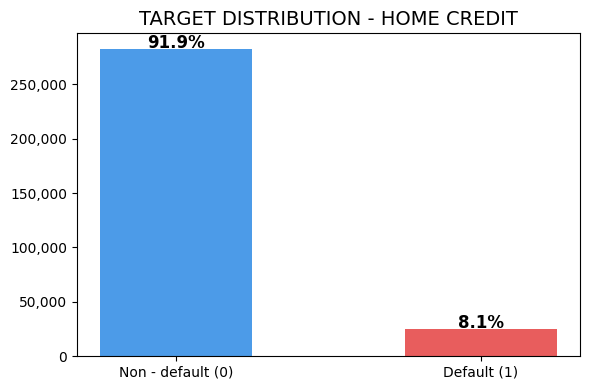

In [25]:
import matplotlib.pyplot as plt

target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Non - default (0)', 'Default (1)'],
    target_counts.values,
    color=['#4C9BE8', '#E85D5D'],
    width=0.5
)

for bar, pct in zip(bars, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'{pct}%',
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('TARGET DISTRIBUTION - HOME CREDIT', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## B3. Split TRƯỚC

In [26]:
HC_RAW_COLS = [c for c in df.columns if c != 'TARGET']

X_raw = df[HC_RAW_COLS].copy()
y     = df['TARGET'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

print(f'Train: {X_train_raw.shape} | Test: {X_test_raw.shape}')
print(f'Bad rate — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}')

n_good = (y_train == 0).sum()
n_bad  = (y_train == 1).sum()
bad_w  = n_good / n_bad
print(f'Class weight (bad): {bad_w:.2f}')

Train: (246008, 115) | Test: (61503, 115)
Bad rate — train: 0.0807 | test: 0.0807
Class weight (bad): 11.39


##  B4. Feature Engineering

In [27]:
# ── Feature Engineering: tạo biến mới ─────────────────────────────

# 1. Tỉ lệ & ratio tài chính
df['CREDIT_INCOME_RATIO']     = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO']    = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_TERM']             = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
df['GOODS_CREDIT_RATIO']      = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)
df['INCOME_PER_PERSON']       = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['CHILDREN_RATIO']          = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)

# 2. Tuổi & thâm niên
df['AGE_YEARS']               = df['DAYS_BIRTH'] / -365
df['EMPLOYED_YEARS']          = df['DAYS_EMPLOYED'].clip(upper=0) / -365  # clip loại outlier 365243
df['EMPLOYED_TO_AGE_RATIO']   = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)
df['ID_PUBLISH_YEARS']        = df['DAYS_ID_PUBLISH'] / -365
df['REGISTRATION_YEARS']      = df['DAYS_REGISTRATION'] / -365
df['PHONE_CHANGE_YEARS']      = df['DAYS_LAST_PHONE_CHANGE'] / -365


# 3. Social circle risk
df['SOCIAL_DEF_RATE_30']      = df['DEF_30_CNT_SOCIAL_CIRCLE'] / (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
df['SOCIAL_DEF_RATE_60']      = df['DEF_60_CNT_SOCIAL_CIRCLE'] / (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)

# 4. Credit bureau enquiries
df['AMT_REQ_CREDIT_TOTAL']    = (
    df['AMT_REQ_CREDIT_BUREAU_HOUR'] +
    df['AMT_REQ_CREDIT_BUREAU_DAY']  +
    df['AMT_REQ_CREDIT_BUREAU_WEEK'] +
    df['AMT_REQ_CREDIT_BUREAU_MON']  +
    df['AMT_REQ_CREDIT_BUREAU_QRT']  +
    df['AMT_REQ_CREDIT_BUREAU_YEAR']
)

# 5. Previous application features
df['PREV_CREDIT_DIFF']        = df['prev_amt_credit_mean'] - df['prev_amt_application_mean']
df['PREV_CREDIT_APP_RATIO']   = df['prev_amt_credit_mean'] / (df['prev_amt_application_mean'] + 1)

# thêm
df['PREV_APPROVAL_RATIO'] = df['prev_approved_count'] / (df['prev_count'] + 1)
df['PREV_REFUSED_RATIO']  = df['prev_refused_count']  / (df['prev_count'] + 1)


new_features = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'GOODS_CREDIT_RATIO',
    'INCOME_PER_PERSON', 'CHILDREN_RATIO',
    'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_TO_AGE_RATIO',
    'ID_PUBLISH_YEARS', 'REGISTRATION_YEARS', 'PHONE_CHANGE_YEARS',

    'SOCIAL_DEF_RATE_30', 'SOCIAL_DEF_RATE_60',
    'AMT_REQ_CREDIT_TOTAL',
    'PREV_CREDIT_DIFF', 'PREV_CREDIT_APP_RATIO',
    'PREV_APPROVAL_RATIO', 'PREV_REFUSED_RATIO'

]

print(f"Đã tạo {len(new_features)} features mới")
print(f"Shape mới: {df.shape}")

# Re-split với cùng index (bảo đảm train/test split nhất quán)
X_fe = df.drop(columns=['TARGET'])
X_train_fe = X_fe.loc[X_train_raw.index].copy()
X_test_fe  = X_fe.loc[X_test_raw.index].copy()

Đã tạo 19 features mới
Shape mới: (307511, 135)


## B5. Preprocessing — Baseline (impute → cap → WOE → scale)

In [28]:
X_train_bl = X_train_fe.copy()
X_test_bl  = X_test_fe.copy()


# Impute AMT_INCOME_TOTAL theo nhóm tuổi
X_train_bl['_age_bin'] = pd.cut(X_train_bl['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_test_bl['_age_bin']  = pd.cut(X_test_bl['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_train_bl, X_test_bl = impute_median_group(
    X_train_bl, X_test_bl, '_age_bin', 'AMT_INCOME_TOTAL')
X_train_bl.drop(columns='_age_bin', inplace=True)
X_test_bl.drop(columns='_age_bin',  inplace=True)

# Impute toàn bộ numeric còn lại
X_train_bl, X_test_bl = impute_all_numeric(X_train_bl, X_test_bl)

# Cap outliers
X_train_bl, X_test_bl = cap_iqr(X_train_bl, X_test_bl)

# WOE + scale
X_train_bl, X_test_bl, woe_hc, scaler_hc = apply_woe_scale(
    X_train_bl, X_test_bl, y_train)

print(f'Baseline input: train={X_train_bl.shape} | test={X_test_bl.shape}')

Baseline input: train=(246008, 134) | test=(61503, 134)


## B6. Baseline models

A6. Baseline Models — Home Credit
  Training Logistic Regression ... (9.0s)
  [test] AUC=0.7683  Gini=0.5366  KS=0.4066  F1(bad)=0.2700
  [train] AUC=0.7684  Gini=0.5368  KS=0.4030  F1(bad)=0.2699
  Training Decision Tree ... (15.3s)
  [test] AUC=0.7261  Gini=0.4522  KS=0.3378  F1(bad)=0.2483
  [train] AUC=0.7408  Gini=0.4815  KS=0.3616  F1(bad)=0.2561
  Training Random Forest ... (129.2s)
  [test] AUC=0.7595  Gini=0.5189  KS=0.3897  F1(bad)=0.2631
  [train] AUC=0.7897  Gini=0.5793  KS=0.4324  F1(bad)=0.2868
  Training XGBoost ... (8.5s)
  [test] AUC=0.7659  Gini=0.5318  KS=0.4035  F1(bad)=0.2677
  [train] AUC=0.9060  Gini=0.8121  KS=0.6609  F1(bad)=0.3999
  Training LightGBM ... (11.1s)
  [test] AUC=0.7802  Gini=0.5603  KS=0.4241  F1(bad)=0.2825
  [train] AUC=0.8207  Gini=0.6415  KS=0.4833  F1(bad)=0.3030
  Training CatBoost ... (78.9s)
  [test] AUC=0.7772  Gini=0.5544  KS=0.4202  F1(bad)=0.2804
  [train] AUC=0.9130  Gini=0.8261  KS=0.6804  F1(bad)=0.4174


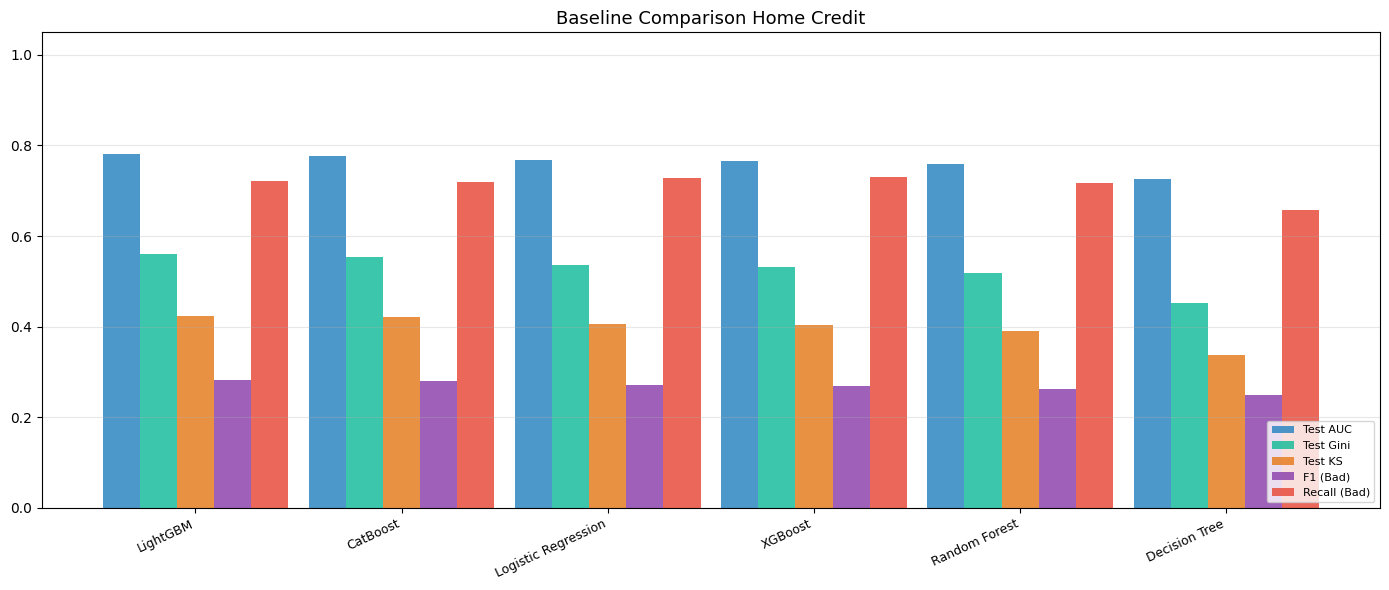

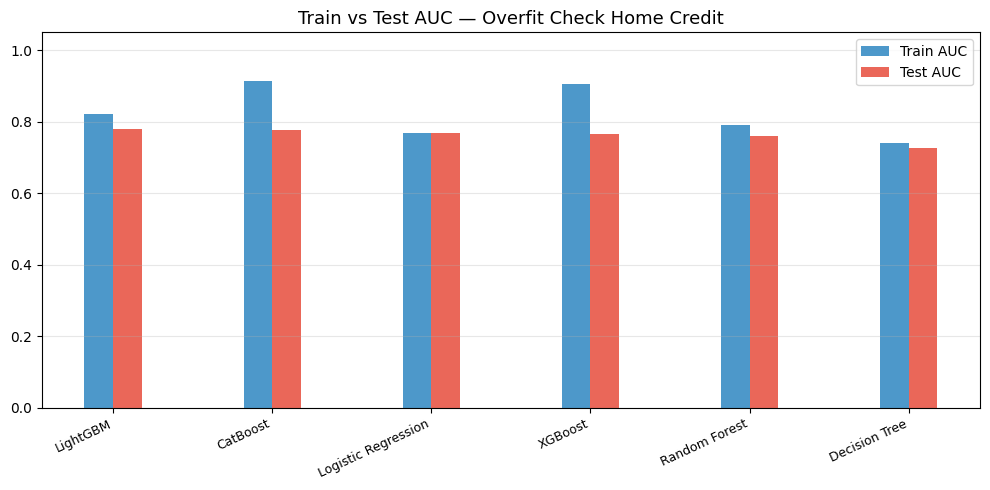

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8207,0.7802,0.5603,0.4241,0.1756,0.7215,0.7026,0.2825,3582,16812,39726,1383,0.4844,11.11
1,CatBoost,0.9130,0.7772,0.5544,0.4202,0.1741,0.7204,0.6998,0.2804,3577,16974,39564,1388,0.4059,78.86
2,Logistic Regression,0.7684,0.7683,0.5366,0.4066,0.1657,0.7289,0.6777,0.2700,3619,18225,38313,1346,0.4812,9.01
3,XGBoost,0.9060,0.7659,0.5318,0.4035,0.1639,0.7311,0.6724,0.2677,3630,18522,38016,1335,0.3886,8.50
4,Random Forest,0.7897,0.7595,0.5189,0.3897,0.1611,0.7182,0.6715,0.2631,3566,18575,37963,1399,0.4697,129.18
5,Decision Tree,0.7408,0.7261,0.4522,0.3378,0.1531,0.6572,0.6806,0.2483,3263,18056,38482,1702,0.5151,15.33


In [29]:
print('='*60)
print('A6. Baseline Models — Home Credit')
print('='*60)
models_hc     = build_baseline_models(bad_w)
results_hc    = train_baseline_models(models_hc, X_train_bl, X_test_bl,
                                       y_train, y_test)
df_summary_hc = summarize_results(results_hc)
plot_baseline(df_summary_hc, title_suffix='Home Credit')
# df_summary_hc.to_csv(f'{OUTPUT_DIR}/summary_hc_baseline.csv', index=False)
df_summary_hc

In [30]:
X_train_bl.shape

(246008, 134)

## B7. TabNet

In [31]:
print('='*60)
print('TabNet — Home Credit')
print('='*60)


# Preprocessing TabNet với FE features
X_train_fe_prep = X_train_fe.copy()
X_test_fe_prep  = X_test_fe.copy()
X_train_fe_prep['_age_bin'] = pd.cut(X_train_fe_prep['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_test_fe_prep['_age_bin']  = pd.cut(X_test_fe_prep['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_train_fe_prep, X_test_fe_prep = impute_median_group(
    X_train_fe_prep, X_test_fe_prep, '_age_bin', 'AMT_INCOME_TOTAL')
X_train_fe_prep.drop(columns='_age_bin', inplace=True)
X_test_fe_prep.drop(columns='_age_bin',  inplace=True)
X_train_fe_prep, X_test_fe_prep = impute_all_numeric(
    X_train_fe_prep, X_test_fe_prep)
X_train_tn, X_test_tn, qt_hc = preprocess_for_tabnet(
    X_train_fe_prep, X_test_fe_prep)

X_fe_tr_np = X_train_tn.values.astype(np.float32)
X_fe_te_np = X_test_tn.values.astype(np.float32)
class_w_hc = np.where(y_train.values == 1, bad_w, 1.0)

print(f'\nWith-FE input: {X_fe_tr_np.shape[1]} features')


TabNet — Home Credit
  TabNet input: train=(246008, 134) | test=(61503, 134)

With-FE input: 134 features


In [32]:
tabnet_hc_fe_default = TabNetClassifier(
    device_name='auto', verbose=10, seed=42)

print('\nTraining TabNet default (with FE) ...')
t0 = time.time()
tabnet_hc_fe_default.fit(
    X_fe_tr_np, y_train.values.astype(np.int64),
    eval_set=[(X_fe_te_np, y_test.values.astype(np.int64))],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=100, patience=15, batch_size=1024, virtual_batch_size=128,
    weights=class_w_hc, drop_last=False)
tabnet_hc_fe_default_time = time.time() - t0

tabnet_hc_fe_default_train = evaluate(tabnet_hc_fe_default, X_fe_tr_np,
                                       y_train.values.astype(np.int64), label='train')
tabnet_hc_fe_default_test  = evaluate(tabnet_hc_fe_default, X_fe_te_np,
                                       y_test.values.astype(np.int64),  label='test')
df_summary_hc = append_to_summary(df_summary_hc, 'TabNet (default)',
                                   tabnet_hc_fe_default_train, tabnet_hc_fe_default_test,
                                   train_time=round(tabnet_hc_fe_default_time, 2))



Training TabNet default (with FE) ...
epoch 0  | loss: 0.63734 | test_auc: 0.72869 |  0:00:14s
epoch 10 | loss: 0.57236 | test_auc: 0.77055 |  0:02:24s
epoch 20 | loss: 0.5441  | test_auc: 0.7638  |  0:04:33s

Early stopping occurred at epoch 26 with best_epoch = 11 and best_test_auc = 0.77214
  [train] AUC=0.7796  Gini=0.5593  KS=0.4184  F1(bad)=0.2762
  [test] AUC=0.7721  Gini=0.5443  KS=0.4109  F1(bad)=0.2703


In [33]:
df_summary_hc

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8207,0.7802,0.5603,0.4241,0.1756,0.7215,0.7026,0.2825,3582,16812,39726,1383,0.4844,11.11
1,CatBoost,0.9130,0.7772,0.5544,0.4202,0.1741,0.7204,0.6998,0.2804,3577,16974,39564,1388,0.4059,78.86
2,TabNet (default),0.7796,0.7721,0.5443,0.4109,0.1655,0.7376,0.6733,0.2703,3662,18470,38068,1303,0.4646,389.59
3,Logistic Regression,0.7684,0.7683,0.5366,0.4066,0.1657,0.7289,0.6777,0.2700,3619,18225,38313,1346,0.4812,9.01
4,XGBoost,0.9060,0.7659,0.5318,0.4035,0.1639,0.7311,0.6724,0.2677,3630,18522,38016,1335,0.3886,8.50
5,Random Forest,0.7897,0.7595,0.5189,0.3897,0.1611,0.7182,0.6715,0.2631,3566,18575,37963,1399,0.4697,129.18
6,Decision Tree,0.7408,0.7261,0.4522,0.3378,0.1531,0.6572,0.6806,0.2483,3263,18056,38482,1702,0.5151,15.33


## B8. Tabnet Improved

In [34]:

variants = [
    {'name': 'TabNet + MHA + BCE Loss',    'use_mha': True,  'loss_type': 'bce'},
    {'name': 'TabNet + no MHA + Focal Loss',       'use_mha': False, 'loss_type': 'focal'},
    {'name': 'TabNet + MHA + Focal Loss',   'use_mha': True,  'loss_type': 'focal'},  # proposed
]

ablation_results = {}
for v in variants:
    print(f"\n=== Training: {v['name']} ===")
    wrapper, tr_m, te_m, hist, raw_model, dev = train_improved_tabnet(
            X_fe_tr_np, X_fe_te_np,
            y_train, y_test,
            bad_w,
        
            # TabNet default
            n_d=8,
            n_steps=3,
            n_heads=1,        
            d_model=8,         
        
            gamma=1.3,
            lambda_sparse=1e-3,
            focal_gamma=2.0,    
        
            dropout=0.0,
        
            lr=0.02,
            weight_decay=0.0,
            batch_size=1024,
        
            loss_type=v['loss_type'],
            use_mha=v['use_mha'],
            max_epochs=100,
            patience=15,
            warmup_epochs=0,
        
            seed=42,
        )
    ablation_results[v['name']] = {'train': tr_m, 'test': te_m, 'history': hist}
    df_summary_hc = append_to_summary(df_summary_hc, v['name'], tr_m, te_m, train_time=None)

print('\n done')
df_summary_hc


=== Training: TabNet + MHA + BCE Loss ===
    Epoch   1 | test_auc=0.77185 | 9s
    Epoch  10 | test_auc=0.77578 | 89s
    Epoch  20 | test_auc=0.77197 | 179s
    Early stop @ epoch 22 | best=0.77807
  [train] AUC=0.7868  Gini=0.5736  KS=0.4301  F1(bad)=0.2776
  [test] AUC=0.7781  Gini=0.5561  KS=0.4175  F1(bad)=0.2951
  Done 201.7s | Train AUC=0.7868 | Test AUC=0.7781 | Gap=0.0087

=== Training: TabNet + no MHA + Focal Loss ===
    Epoch   1 | test_auc=0.76781 | 6s
    Epoch  10 | test_auc=0.77423 | 59s
    Epoch  20 | test_auc=0.77314 | 119s
    Early stop @ epoch 20 | best=0.77550
  [train] AUC=0.7810  Gini=0.5619  KS=0.4219  F1(bad)=0.2823
  [test] AUC=0.7755  Gini=0.5510  KS=0.4147  F1(bad)=0.2870
  Done 121.7s | Train AUC=0.7810 | Test AUC=0.7755 | Gap=0.0055

=== Training: TabNet + MHA + Focal Loss ===
    Epoch   1 | test_auc=0.77073 | 9s
    Epoch  10 | test_auc=0.77511 | 91s
    Epoch  20 | test_auc=0.77575 | 182s
    Early stop @ epoch 23 | best=0.77951
  [train] AUC=0.7883

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8207,0.7802,0.5603,0.4241,0.1756,0.7215,0.7026,0.2825,3582,16812,39726,1383,0.4844,11.11
1,TabNet + MHA + Focal Loss,0.7883,0.7795,0.5590,0.4237,0.1779,0.7132,0.7105,0.2847,3541,16367,40171,1424,0.5811,NaN
2,TabNet + MHA + BCE Loss,0.7868,0.7781,0.5561,0.4175,0.1893,0.6693,0.7482,0.2951,3323,14234,42304,1642,0.5370,NaN
3,CatBoost,0.9130,0.7772,0.5544,0.4202,0.1741,0.7204,0.6998,0.2804,3577,16974,39564,1388,0.4059,78.86
4,TabNet + no MHA + Focal Loss,0.7810,0.7755,0.5510,0.4147,0.1814,0.6868,0.7279,0.2870,3410,15384,41154,1555,0.5823,NaN
5,TabNet (default),0.7796,0.7721,0.5443,0.4109,0.1655,0.7376,0.6733,0.2703,3662,18470,38068,1303,0.4646,389.59
6,Logistic Regression,0.7684,0.7683,0.5366,0.4066,0.1657,0.7289,0.6777,0.2700,3619,18225,38313,1346,0.4812,9.01
7,XGBoost,0.9060,0.7659,0.5318,0.4035,0.1639,0.7311,0.6724,0.2677,3630,18522,38016,1335,0.3886,8.50
8,Random Forest,0.7897,0.7595,0.5189,0.3897,0.1611,0.7182,0.6715,0.2631,3566,18575,37963,1399,0.4697,129.18
9,Decision Tree,0.7408,0.7261,0.4522,0.3378,0.1531,0.6572,0.6806,0.2483,3263,18056,38482,1702,0.5151,15.33


In [36]:
# Chạy thêm 2–3 runs cuối với config đang thắng, chỉnh patience
for patience, warmup in [(20, 0), (15, 5), (20, 10)]:
    _, tr_m, te_m, *_ = train_improved_tabnet(
        X_fe_tr_np, X_fe_te_np, y_train, y_test, bad_w,
        n_d=8, n_steps=3, n_heads=1, d_model=8,
        gamma=1.3, lambda_sparse=1e-3, focal_gamma=2.0,
        dropout=0.0, lr=0.02, weight_decay=0.0, batch_size=1024,
        loss_type='focal', use_mha=True,
        max_epochs=150, patience=patience, warmup_epochs=warmup, seed=42,
    )
    print(f"patience={patience} warmup={warmup}: Test={te_m['auc']:.4f}")

    Epoch   1 | test_auc=0.77073 | 9s
    Epoch  10 | test_auc=0.77504 | 91s
    Epoch  20 | test_auc=0.77241 | 182s
    Early stop @ epoch 28 | best=0.77864
  [train] AUC=0.7881  Gini=0.5761  KS=0.4324  F1(bad)=0.2853
  [test] AUC=0.7786  Gini=0.5573  KS=0.4206  F1(bad)=0.2808
  Done 259.5s | Train AUC=0.7881 | Test AUC=0.7786 | Gap=0.0094
patience=20 warmup=0: Test=0.7786
    Epoch   1 | test_auc=0.76844 | 9s
    Epoch  10 | test_auc=0.77490 | 90s
    Epoch  20 | test_auc=0.77220 | 180s
    Early stop @ epoch 21 | best=0.77792
  [train] AUC=0.7835  Gini=0.5670  KS=0.4247  F1(bad)=0.2824
  [test] AUC=0.7779  Gini=0.5558  KS=0.4174  F1(bad)=0.2867
  Done 194.4s | Train AUC=0.7835 | Test AUC=0.7779 | Gap=0.0056
patience=15 warmup=5: Test=0.7779
    Epoch   1 | test_auc=0.76844 | 9s
    Epoch  10 | test_auc=0.77293 | 90s
    Epoch  20 | test_auc=0.77189 | 181s
    Early stop @ epoch 28 | best=0.77760
  [train] AUC=0.7868  Gini=0.5736  KS=0.4298  F1(bad)=0.2887
  [test] AUC=0.7776  Gini=0

# PHẦN B - THỐNG KÊ & BÁO CÁO


── Risk Tiering (Home Credit) ──
            tier  Count  Bad_Rate  Avg_Prob  Bad_Rate_pct
 Medium (10–30%)   2121  0.008487  0.260903          0.85
   High (30–50%)  27423  0.025234  0.418419          2.52
Very High (>50%)  31959  0.133139  0.639019         13.31


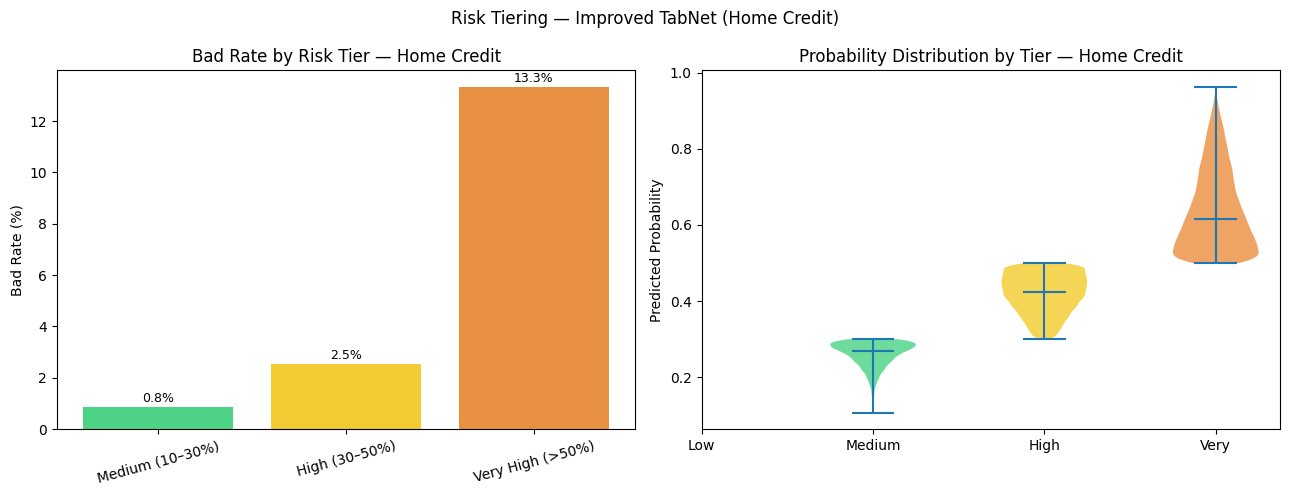

In [38]:
# HC
stats_hc = run_risk_tiering(
    wrapper, X_fe_te_np, y_test.values.astype(np.int64),
    tag='Home Credit',
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['Low (<20%)', 'Medium (20–40%)', 'High (40–60%)', 'Very High (>60%)']
)

In [40]:
# ============================================================
# 1. TabNet default (pytorch-tabnet gốc)
# ============================================================
p_default_hc = tabnet_hc_fe_default.predict_proba(X_fe_te_np)[:, 1]
results_hc['TabNet'] = {
    'y_true': y_test.values.astype(np.int64),
    'y_prob': p_default_hc,
    'auc': roc_auc_score(y_test, p_default_hc),
}

# ============================================================
# 2. Improved TabNet (MHA + Focal Loss)
# ============================================================
p_mha_hc = wrapper.predict_proba(X_fe_te_np)[:, 1]
results_hc['TabNet + MHA + Focal Loss'] = {
    'y_true': y_test.values.astype(np.int64),
    'y_prob': p_mha_hc,
    'auc': te_m['auc'],
}

print('✓ results_hc hiện có:')
for k in results_hc:
    print(' -', k)

✓ results_hc hiện có:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - XGBoost
 - LightGBM
 - CatBoost
 - TabNet
 - TabNet + MHA + Focal Loss


In [43]:
df_summary_hc['Model'] = df_summary_hc['Model'].replace({'TabNet (default)': 'TabNet'})
df_summary_hc

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8207,0.7802,0.5603,0.4241,0.1756,0.7215,0.7026,0.2825,3582,16812,39726,1383,0.4844,11.11
1,TabNet + MHA + Focal Loss,0.7883,0.7795,0.5590,0.4237,0.1779,0.7132,0.7105,0.2847,3541,16367,40171,1424,0.5811,NaN
2,TabNet + MHA + BCE Loss,0.7868,0.7781,0.5561,0.4175,0.1893,0.6693,0.7482,0.2951,3323,14234,42304,1642,0.5370,NaN
3,CatBoost,0.9130,0.7772,0.5544,0.4202,0.1741,0.7204,0.6998,0.2804,3577,16974,39564,1388,0.4059,78.86
4,TabNet + no MHA + Focal Loss,0.7810,0.7755,0.5510,0.4147,0.1814,0.6868,0.7279,0.2870,3410,15384,41154,1555,0.5823,NaN
5,TabNet,0.7796,0.7721,0.5443,0.4109,0.1655,0.7376,0.6733,0.2703,3662,18470,38068,1303,0.4646,389.59
6,Logistic Regression,0.7684,0.7683,0.5366,0.4066,0.1657,0.7289,0.6777,0.2700,3619,18225,38313,1346,0.4812,9.01
7,XGBoost,0.9060,0.7659,0.5318,0.4035,0.1639,0.7311,0.6724,0.2677,3630,18522,38016,1335,0.3886,8.50
8,Random Forest,0.7897,0.7595,0.5189,0.3897,0.1611,0.7182,0.6715,0.2631,3566,18575,37963,1399,0.4697,129.18
9,Decision Tree,0.7408,0.7261,0.4522,0.3378,0.1531,0.6572,0.6806,0.2483,3263,18056,38482,1702,0.5151,15.33


C. Thống kê & Báo cáo — Home Credit

── C1a. Summary — Home Credit ──
                    Model  Train AUC  Test AUC  Test Gini  Test KS  F1 (Bad)
                 LightGBM     0.8207    0.7802     0.5603   0.4241    0.2825
TabNet + MHA + Focal Loss     0.7883    0.7795     0.5590   0.4237    0.2847
                 CatBoost     0.9130    0.7772     0.5544   0.4202    0.2804
                   TabNet     0.7796    0.7721     0.5443   0.4109    0.2703
      Logistic Regression     0.7684    0.7683     0.5366   0.4066    0.2700
                  XGBoost     0.9060    0.7659     0.5318   0.4035    0.2677
            Random Forest     0.7897    0.7595     0.5189   0.3897    0.2631
            Decision Tree     0.7408    0.7261     0.4522   0.3378    0.2483

── C1b. Ablation Study — TabNet (MHA / Focal Loss) ──
                       Model  Train AUC  Test AUC  Test Gini  Test KS  F1 (Bad)
   TabNet + MHA + Focal Loss     0.7883    0.7795     0.5590   0.4237    0.2847
     TabNet + MHA + BC

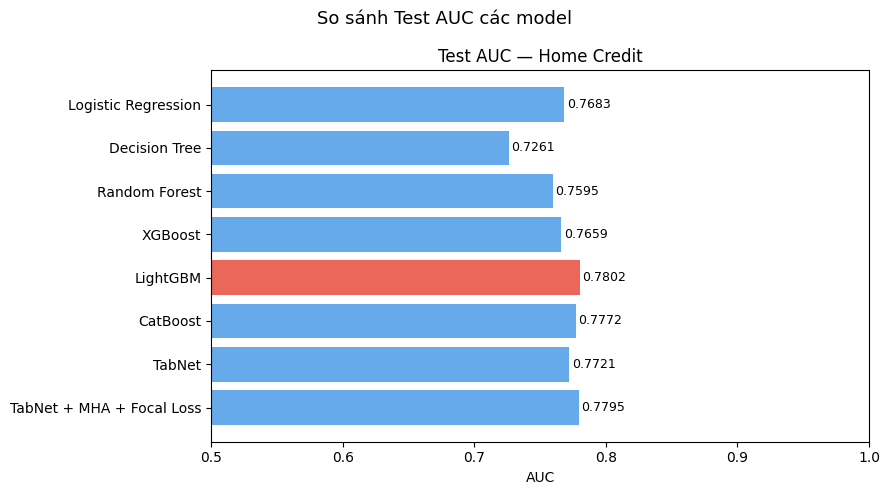


── C3. ROC Curve ──


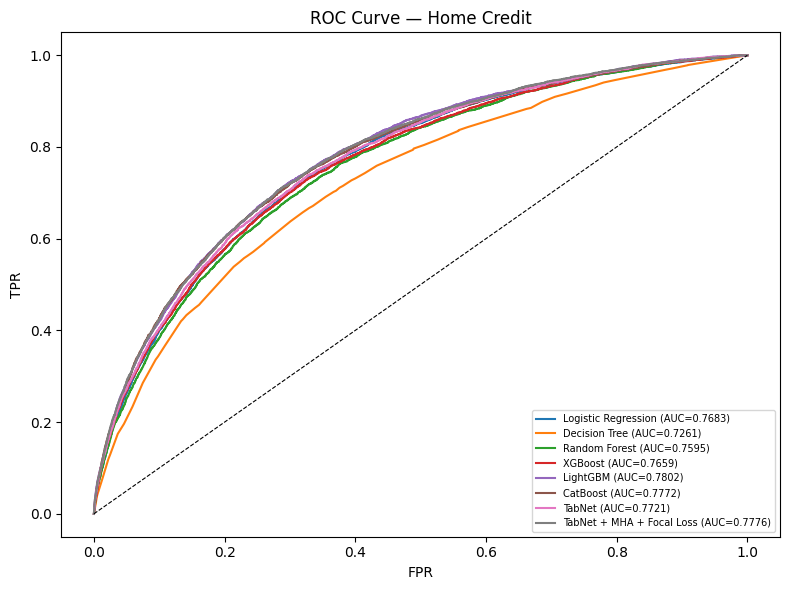


── C4. KS Chart ──


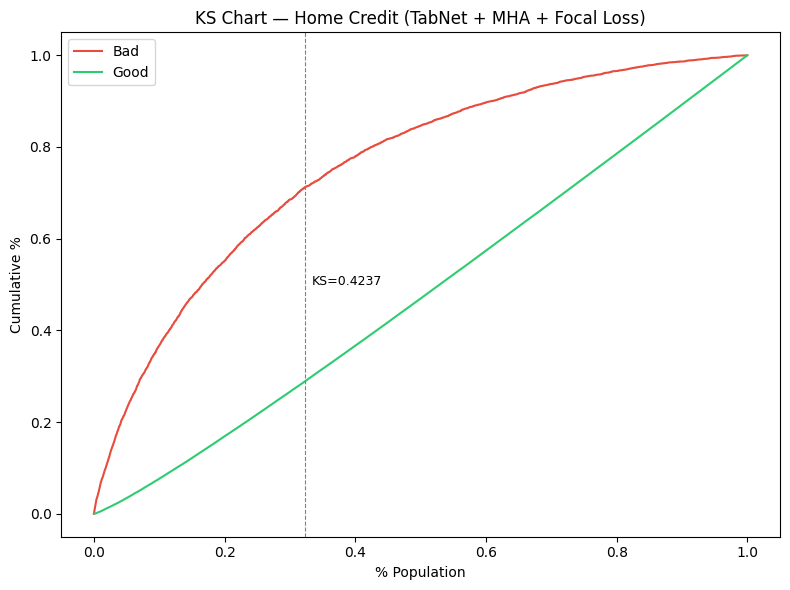


── C5. Confusion Matrix ──

── Classification Report — Home Credit (TabNet + MHA + Focal Loss) ──
              precision    recall  f1-score   support

        Good       0.98      0.51      0.67     56538
         Bad       0.13      0.86      0.23      4965

    accuracy                           0.54     61503
   macro avg       0.55      0.68      0.45     61503
weighted avg       0.91      0.54      0.63     61503



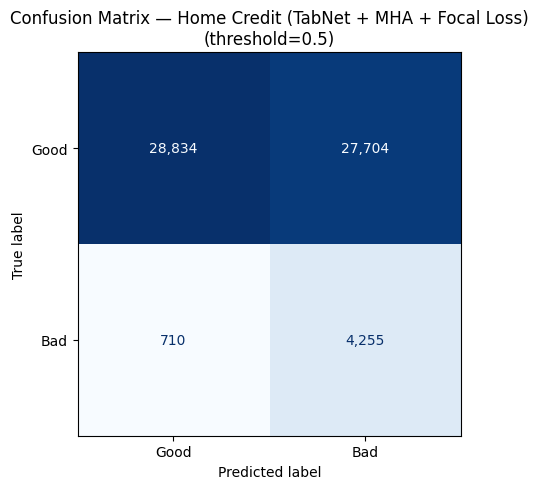

In [51]:
print('='*60)
print('C. Thống kê & Báo cáo — Home Credit')
print('='*60)

import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

# ============================================================
# Danh sách model chính
# ============================================================
main_models_order_hc = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost',
    'LightGBM',
    'CatBoost',
    'TabNet',
    'TabNet + MHA + Focal Loss',
]

# ============================================================
# C1a. Summary Table — các model chính
# ============================================================
print('\n── C1a. Summary — Home Credit ──')
df_c1a_hc = df_summary_hc[df_summary_hc['Model'].isin(main_models_order_hc)].copy()
df_c1a_hc = df_c1a_hc.sort_values('Test AUC', ascending=False).reset_index(drop=True)
print(df_c1a_hc[['Model','Train AUC','Test AUC','Test Gini','Test KS','F1 (Bad)']].to_string(index=False))

# ============================================================
# C1b. Ablation Table — các biến thể TabNet
# ============================================================
ablation_models_order_hc = [
    'TabNet + MHA + BCE Loss',
    'TabNet + no MHA + Focal Loss',
    'TabNet + MHA + Focal Loss',
    'TabNet',
]
print('\n── C1b. Ablation Study — TabNet (MHA / Focal Loss) ──')
df_c1b_hc = df_summary_hc[df_summary_hc['Model'].isin(ablation_models_order_hc)].copy()
df_c1b_hc = df_c1b_hc.sort_values('Test AUC', ascending=False).reset_index(drop=True)
print(df_c1b_hc[['Model','Train AUC','Test AUC','Test Gini','Test KS','F1 (Bad)']].to_string(index=False))

# ============================================================
# C2. Bar chart so sánh Test AUC
# ============================================================
print('\n── C2. Bar chart ──')
df_c2_hc = df_summary_hc[df_summary_hc['Model'].isin(main_models_order_hc)].copy()
df_c2_hc['Model'] = pd.Categorical(df_c2_hc['Model'], categories=main_models_order_hc, ordered=True)
df_c2_hc = df_c2_hc.sort_values('Model')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C' if v == df_c2_hc['Test AUC'].max() else '#4C9BE8' for v in df_c2_hc['Test AUC']]
bars = ax.barh(df_c2_hc['Model'], df_c2_hc['Test AUC'], color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_xlim(0.5, 1.0)
ax.set_title('Test AUC — Home Credit')
ax.set_xlabel('AUC')
for bar, v in zip(bars, df_c2_hc['Test AUC']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('So sánh Test AUC các model', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# C3. ROC Curve
# ============================================================
print('\n── C3. ROC Curve ──')
def plot_roc_all(results, title, ax, order=None):
    keys = order if order else list(results.keys())
    for name in keys:
        if name not in results:
            continue
        res = results[name]
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
        ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})", lw=1.5)
    ax.plot([0,1],[0,1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {title}')
    ax.legend(fontsize=7, loc='lower right')

fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_all(results_hc_main, 'Home Credit', ax, order=main_models_order_hc)
plt.tight_layout()
plt.show()
# results_hc_main = {k: v for k, v in results_hc.items() if k in main_models_order_hc}

# fig, ax = plt.subplots(figsize=(8, 6))
# plot_roc_all(results_hc_main, 'Home Credit', ax, order=main_models_order_hc)
# plt.tight_layout()
# plt.show()

# ============================================================
# C4. KS Chart — best model
# ============================================================
print('\n── C4. KS Chart ──')
def plot_ks(y_true, y_prob, title, ax):
    df_ks = pd.DataFrame({'prob': y_prob, 'actual': y_true})
    df_ks = df_ks.sort_values('prob', ascending=False).reset_index(drop=True)
    df_ks['cum_bad']  = (df_ks['actual'] == 1).cumsum() / (df_ks['actual'] == 1).sum()
    df_ks['cum_good'] = (df_ks['actual'] == 0).cumsum() / (df_ks['actual'] == 0).sum()
    df_ks['ks'] = df_ks['cum_bad'] - df_ks['cum_good']
    pct = np.linspace(0, 1, len(df_ks))
    ax.plot(pct, df_ks['cum_bad'],  label='Bad',  color='#E74C3C')
    ax.plot(pct, df_ks['cum_good'], label='Good', color='#2ECC71')
    ks_max = df_ks['ks'].max()
    ks_idx = df_ks['ks'].idxmax()
    ax.axvline(pct[ks_idx], color='gray', linestyle='--', lw=0.8)
    ax.text(pct[ks_idx]+0.01, 0.5, f'KS={ks_max:.4f}', fontsize=9)
    ax.set_title(f'KS Chart — {title}')
    ax.set_xlabel('% Population'); ax.set_ylabel('Cumulative %')
    ax.legend()

# fig, ax = plt.subplots(figsize=(8, 6))
proposed_hc = 'TabNet + MHA + Focal Loss'

fig, ax = plt.subplots(figsize=(8, 6))
plot_ks(results_hc_main[proposed_hc]['y_true'], results_hc_main[proposed_hc]['y_prob'],
        f'Home Credit ({proposed_hc})', ax)
plt.tight_layout()
plt.show()

# ============================================================
# C5. Confusion Matrix — best model
# ============================================================
print('\n── C5. Confusion Matrix ──')
def plot_cm(y_true, y_prob, title, ax, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good','Bad'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    for text in ax.texts:
        text.set_text(f'{int(text.get_text()):,}')
    ax.set_title(f'Confusion Matrix — {title}\n(threshold={threshold})')
    print(f'\n── Classification Report — {title} ──')
    print(classification_report(y_true, y_pred, target_names=['Good','Bad']))

fig, ax = plt.subplots(figsize=(6, 5))
plot_cm(results_hc_main[proposed_hc]['y_true'], results_hc_main[proposed_hc]['y_prob'],
        f'Home Credit ({proposed_hc})', ax)
plt.tight_layout()
plt.show()

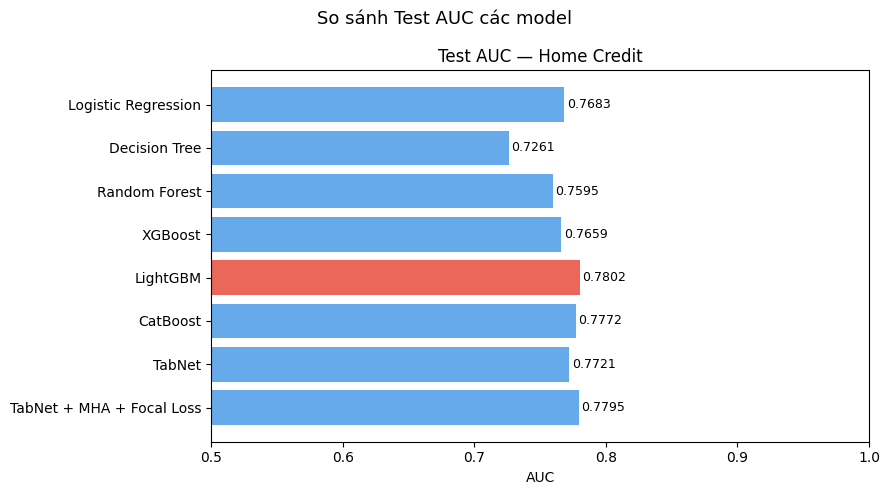

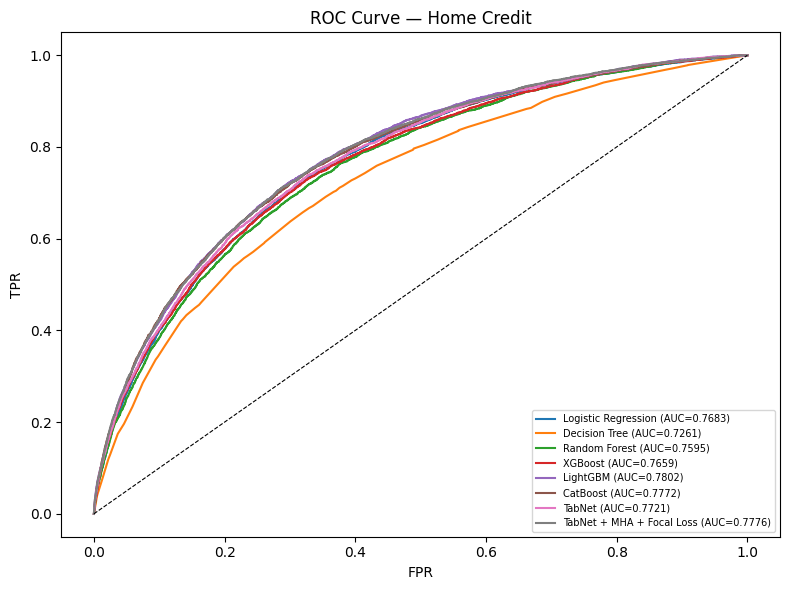

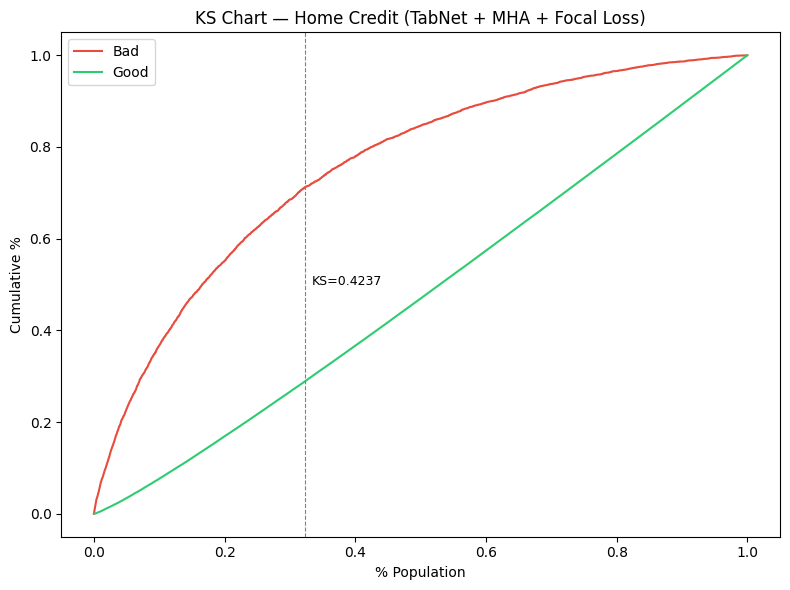


── Classification Report — Home Credit (TabNet + MHA + Focal Loss) ──
              precision    recall  f1-score   support

        Good       0.98      0.51      0.67     56538
         Bad       0.13      0.86      0.23      4965

    accuracy                           0.54     61503
   macro avg       0.55      0.68      0.45     61503
weighted avg       0.91      0.54      0.63     61503



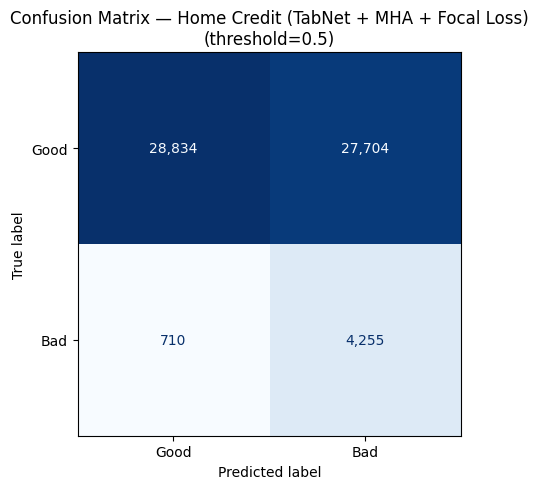


✓ Đã đóng gói: /kaggle/working/demo_package_hc.zip
✓ Kích thước: 327.8 KB
demo_package_hc/
  tables/
    risk_tiering.csv
    full_summary_hc.csv
    C1a_summary_main_models.csv
    C1b_ablation_tabnet.csv
  figures/
    C5_confusion_matrix.png
    C4_ks_chart.png
    C3_roc_curves.png
    C2_auc_comparison.png
    risk_tiering_home_credit.png


In [52]:
# ============================================================
# PHẦN C - SAVE: Đóng gói bảng + hình → HC package
# ============================================================
import os, shutil
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

# ── 0. Thiết lập đường dẫn ───────────────────────────────────
save_dir = '/kaggle/working/demo_package_hc'
for sub in ['figures', 'tables']:
    os.makedirs(f'{save_dir}/{sub}', exist_ok=True)

# ── 1. Bảng kết quả ──────────────────────────────────────────
df_summary_hc.to_csv(f'{save_dir}/tables/full_summary_hc.csv', index=False)
df_c1a_hc.to_csv(f'{save_dir}/tables/C1a_summary_main_models.csv', index=False)
df_c1b_hc.to_csv(f'{save_dir}/tables/C1b_ablation_tabnet.csv', index=False)

risk_csv = f'{OUTPUT_DIR}/risk_tiering_home_credit.csv'
if os.path.exists(risk_csv):
    shutil.copy(risk_csv, f'{save_dir}/tables/risk_tiering.csv')
else:
    print(f'⚠️ Không tìm thấy: {risk_csv}')

# ── 2. Vẽ và lưu hình ────────────────────────────────────────

# C2. Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C' if v == df_c2_hc['Test AUC'].max() else '#4C9BE8' for v in df_c2_hc['Test AUC']]
bars = ax.barh(df_c2_hc['Model'], df_c2_hc['Test AUC'], color=colors, alpha=0.85)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0)
ax.set_title('Test AUC — Home Credit'); ax.set_xlabel('AUC')
for bar, v in zip(bars, df_c2_hc['Test AUC']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('So sánh Test AUC các model', fontsize=13)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/C2_auc_comparison.png', dpi=150)
plt.show()

# C3. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_all(results_hc_main, 'Home Credit', ax, order=main_models_order_hc)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/C3_roc_curves.png', dpi=150)
plt.show()

# C4. KS Chart
fig, ax = plt.subplots(figsize=(8, 6))
plot_ks(results_hc_main[proposed_hc]['y_true'], results_hc_main[proposed_hc]['y_prob'],
        f'Home Credit ({proposed_hc})', ax)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/C4_ks_chart.png', dpi=150)
plt.show()

# C5. Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
plot_cm(results_hc_main[proposed_hc]['y_true'], results_hc_main[proposed_hc]['y_prob'],
        f'Home Credit ({proposed_hc})', ax)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/C5_confusion_matrix.png', dpi=150)
plt.show()

# Risk tiering
risk_png = f'{OUTPUT_DIR}/risk_tiering_home_credit.png'
if os.path.exists(risk_png):
    shutil.copy(risk_png, f'{save_dir}/figures/risk_tiering_home_credit.png')
else:
    print(f'⚠️ Không tìm thấy: {risk_png}')

# ── 3. Nén thành 1 file ZIP ──────────────────────────────────
zip_base = '/kaggle/working/demo_package_hc'
shutil.make_archive(zip_base, 'zip', save_dir)
zip_path = zip_base + '.zip'

print(f'\n✓ Đã đóng gói: {zip_path}')
print(f'✓ Kích thước: {os.path.getsize(zip_path)/1024:.1f} KB')
for root, dirs, files in os.walk(save_dir):
    level = root.replace(save_dir, '').count(os.sep)
    print('  '*level + os.path.basename(root) + '/')
    for f_ in files:
        print('  '*(level+1) + f_)